In [1]:
from test_pipe import *

import nest_asyncio
nest_asyncio.apply()

Paper trading mode enabled.
Connecting to IBKR at 127.0.0.1:7497 with client ID 1


In [3]:
# Example usage
ib_conn = IBKRConnection(live_trading=False)
ib_conn.connect()
ib = ib_conn.get_ib()
# print(f"Server time: {ib.reqCurrentTime()}")

strat = MovingAverageStrategy(conn=ib_conn, symbol='AAPL', fast_period=10, slow_period=30)
strat.run_strategy()

# ib_conn.disconnect()

Paper trading mode enabled.
Connecting to IBKR at 127.0.0.1:7497 with client ID 1
Connected to IBKR at 127.0.0.1:7497 with client ID 1
Strategy base class initialized. <class 'ib_insync.ib.IB'>
Moving Average Strategy initialized for AAPL (10/30 periods).
Analysis: Fast MA: 263.42, Slow MA: 265.07, Signal: SELL
Placing SELL order for AAPL.


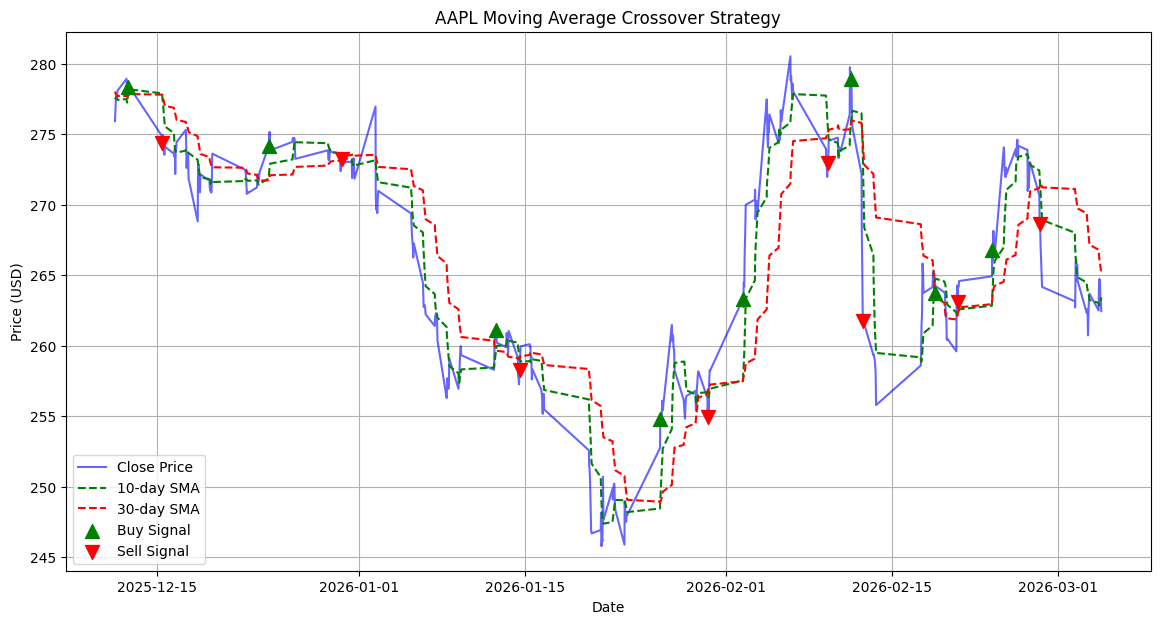

In [4]:
strat.plot_signals(strat.df)

--- Strategy Performance Report ---
Total Return: -6.29%
Annualized Volatility: 21.69%
Sharpe Ratio: -0.846
Sortino Ratio: -1.306
Max Drawdown: -18.83%
Win Rate (Days): 47.00%


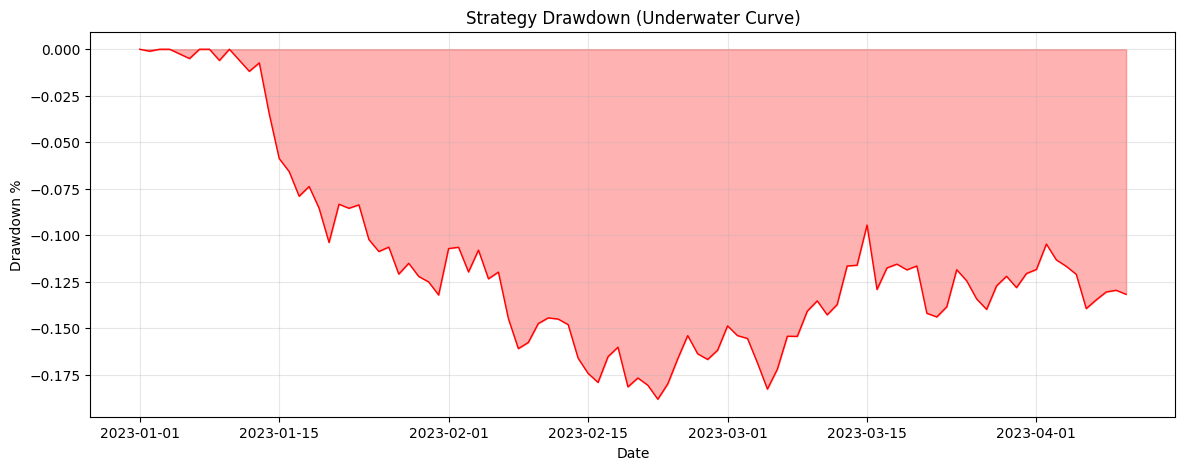

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. EVENT SKELETONS (The Messaging System)
# ==========================================
class Event:
    """Base class for all events."""
    pass

class MarketEvent(Event):
    """Fired when new market data arrives."""
    pass

class SignalEvent(Event):
    """Fired when a strategy triggers a trade signal."""
    def __init__(self, symbol, datetime, signal_type):
        self.symbol = symbol
        self.datetime = datetime
        self.signal_type = signal_type # 'BUY' or 'SELL'

class OrderEvent(Event):
    """Fired when the Portfolio Manager approves a trade."""
    def __init__(self, symbol, order_type, quantity, action):
        self.symbol = symbol
        self.order_type = order_type
        self.quantity = quantity
        self.action = action

class FillEvent(Event):
    """Fired when the broker confirms execution."""
    def __init__(self, symbol, datetime, quantity, fill_price, commission):
        self.symbol = symbol
        self.datetime = datetime
        self.quantity = quantity
        self.fill_price = fill_price
        self.commission = commission

# ==========================================
# 2. QUANTITATIVE EVALUATOR (The Auditor)
# ==========================================
class QuantitativeEvaluator:
    """
    Calculates institutional-grade metrics from a strategy's equity curve.
    Assumes a standard 252 trading days in a year for annualization.
    """
    def __init__(self, risk_free_rate: float = 0.02):
        self.risk_free_rate = risk_free_rate
        self.trading_days_per_year = 252

    def calculate_metrics(self, df: pd.DataFrame) -> dict:
        """
        Takes a DataFrame containing at least 'close' and 'Strategy_Return'
        and calculates core performance metrics.
        """
        # Calculate daily percentage returns from the cumulative strategy return
        df['Daily_Return'] = df['Strategy_Return'].pct_change()
        
        # 1. Total Return
        total_return = df['Strategy_Return'].iloc[-1] - 1.0

        # 2. Annualized Volatility
        daily_volatility = df['Daily_Return'].std()
        annual_volatility = daily_volatility * np.sqrt(self.trading_days_per_year)

        # 3. Sharpe Ratio
        # $S = \frac{R_p - R_f}{\sigma_p}$
        expected_annual_return = df['Daily_Return'].mean() * self.trading_days_per_year
        excess_return = expected_annual_return - self.risk_free_rate
        
        if annual_volatility > 0:
            sharpe_ratio = excess_return / annual_volatility
        else:
            sharpe_ratio = 0.0

        # 4. Sortino Ratio (Downside deviation only)
        negative_returns = df[df['Daily_Return'] < 0]['Daily_Return']
        downside_deviation = negative_returns.std() * np.sqrt(self.trading_days_per_year)
        
        if downside_deviation > 0:
            sortino_ratio = excess_return / downside_deviation
        else:
            sortino_ratio = 0.0

        # 5. Maximum Drawdown
        # $MDD = \frac{\text{Trough Value} - \text{Peak Value}}{\text{Peak Value}}$
        df['Peak'] = df['Strategy_Return'].cummax()
        df['Drawdown'] = (df['Strategy_Return'] - df['Peak']) / df['Peak']
        max_drawdown = df['Drawdown'].min()

        # 6. Win Rate (Approximation based on daily positive movement for this vectorized example)
        winning_days = len(df[df['Daily_Return'] > 0])
        total_trading_days = len(df[df['Daily_Return'] != 0])
        win_rate = winning_days / total_trading_days if total_trading_days > 0 else 0

        metrics = {
            "Total Return": f"{total_return * 100:.2f}%",
            "Annualized Volatility": f"{annual_volatility * 100:.2f}%",
            "Sharpe Ratio": round(sharpe_ratio, 3),
            "Sortino Ratio": round(sortino_ratio, 3),
            "Max Drawdown": f"{max_drawdown * 100:.2f}%",
            "Win Rate (Days)": f"{win_rate * 100:.2f}%"
        }
        
        return metrics

    def plot_drawdown(self, df: pd.DataFrame):
        """Visualizes the underwater/drawdown curve."""
        if 'Drawdown' not in df.columns:
            df['Peak'] = df['Strategy_Return'].cummax()
            df['Drawdown'] = (df['Strategy_Return'] - df['Peak']) / df['Peak']

        plt.figure(figsize=(14, 5))
        plt.fill_between(df.index, df['Drawdown'], 0, color='red', alpha=0.3)
        plt.plot(df.index, df['Drawdown'], color='red', linewidth=1)
        plt.title('Strategy Drawdown (Underwater Curve)')
        plt.xlabel('Date')
        plt.ylabel('Drawdown %')
        plt.grid(True, alpha=0.3)
        plt.show()

# ==========================================
# Example Usage Integration
# ==========================================
if __name__ == "__main__":
    # Mocking the DataFrame generation from your original MovingAverageStrategy
    np.random.seed(42)
    dates = pd.date_range(start='2023-01-01', periods=100, freq='D')
    
    # Simulating a strategy that generated a cumulative return column
    # In reality, this comes directly from: df = strat.test_strategy()
    mock_cumulative_returns = np.cumprod(1 + np.random.normal(0.001, 0.015, 100))
    
    df = pd.DataFrame({
        'close': np.random.uniform(100, 150, 100),
        'Strategy_Return': mock_cumulative_returns
    }, index=dates)

    # Initialize the separated Evaluator class
    evaluator = QuantitativeEvaluator(risk_free_rate=0.02)
    
    # Calculate metrics
    performance_report = evaluator.calculate_metrics(df)
    
    print("--- Strategy Performance Report ---")
    for metric, value in performance_report.items():
        print(f"{metric}: {value}")
        
    # Plot the drawdown
    evaluator.plot_drawdown(df)

In [7]:
# Calculate metrics
performance_report = evaluator.calculate_metrics(strat.df)

print("--- Strategy Performance Report ---")
for metric, value in performance_report.items():
    print(f"{metric}: {value}")
    
# Plot the drawdown
evaluator.plot_drawdown(strat.df)

KeyError: 'Strategy_Return'